In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats as sp_stats

BASE     = Path('..') / 'results' / 'mas' / 'final_dataset'
W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']
W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
T_COLORS  = {'fc': '#2c7bb6', 'star': '#d7191c'}
DS_LABELS = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}
T_LABELS  = {'fc': 'FC', 'star': 'Star'}
CONFIG_ORDER = [f'{t}/W={w}' for t in TOPOS for w in W_VALUES]
CONFIG_COLORS = (
    [T_COLORS['fc']] * 3 + [T_COLORS['star']] * 3
)

## Load Data

In [2]:
def load_tasks():
    rows = []
    for f in sorted(BASE.glob('**/*.json')):
        d    = json.loads(f.read_text())
        reps = d['repetitions']
        rows.append({
            'W':        d['W'],
            'dataset':  d['dataset'],
            'topology': d.get('topology_name', 'fc'),
            'qid':      d['question_id'],
            'accuracy': float(np.mean([r['correct'] for r in reps])),
            'n_reps':   len(reps),
        })
    return pd.DataFrame(rows)

tasks_df = load_tasks()
tasks_df['config'] = tasks_df['topology'] + '/W=' + tasks_df['W'].astype(str)
print(f'Task records: {len(tasks_df):,}')
print(tasks_df.groupby(['dataset', 'topology', 'W'])['accuracy'].mean().round(3).to_string())

Task records: 420
dataset      topology  W
gpqa         fc        1    0.502
                       2    0.497
                       5    0.507
             star      1    0.475
                       2    0.488
                       5    0.478
hiddenbench  fc        1    0.299
                       2    0.321
                       5    0.321
             star      1    0.304
                       2    0.325
                       5    0.329


---
## Normalization

Each question (qid) has 6 config cells within a dataset (2 topologies × 3 W values).
Raw accuracy is confounded by problem difficulty.  We apply three normalizations
**per (dataset, qid)** across those 6 configs:

| Name | Formula | Interpretation |
|------|---------|----------------|
| `acc_minmax` | `(acc - min) / (max - min)` | 0 = worst config for this problem, 1 = best |
| `acc_zscore` | `(acc - mean) / std` | how many SDs above/below mean performance |
| `acc_residual` | `acc - mean` | absolute deviation from mean difficulty |

In [3]:
EPS = 1e-9

def _add_norms(grp):
    acc = grp['accuracy']
    mn, mx, mu, sd = acc.min(), acc.max(), acc.mean(), acc.std()
    grp = grp.copy()
    grp['difficulty']   = mu
    grp['acc_minmax']   = (acc - mn) / (mx - mn + EPS)
    grp['acc_zscore']   = (acc - mu) / (sd + EPS)
    grp['acc_residual'] = acc - mu
    return grp

tasks_df = (
    tasks_df
    .groupby(['dataset', 'qid'], group_keys=False)
    .apply(_add_norms)
    .reset_index(drop=True)
)

print('Normalization complete.')
print()
print('Mean normalized accuracy per config (min-max):')
print(
    tasks_df.groupby(['dataset', 'topology', 'W'])['acc_minmax']
    .mean().round(3).to_string()
)
print()
print('Mean residual accuracy per config:')
print(
    tasks_df.groupby(['dataset', 'topology', 'W'])['acc_residual']
    .mean().round(4).to_string()
)

Normalization complete.

Mean normalized accuracy per config (min-max):
dataset      topology  W
gpqa         fc        1    0.504
                       2    0.486
                       5    0.475
             star      1    0.442
                       2    0.457
                       5    0.445
hiddenbench  fc        1    0.408
                       2    0.457
                       5    0.451
             star      1    0.417
                       2    0.473
                       5    0.516

Mean residual accuracy per config:
dataset      topology  W
gpqa         fc        1    0.0108
                       2    0.0060
                       5    0.0156
             star      1   -0.0159
                       2   -0.0035
                       5   -0.0130
hiddenbench  fc        1   -0.0173
                       2    0.0046
                       5    0.0046
             star      1   -0.0125
                       2    0.0084
                       5    0.0122


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_51420/3811261777.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_add_norms)


---
## Part 1 — Problem Difficulty Distribution

In [4]:
difficulty_df = (
    tasks_df.groupby(['dataset', 'qid'])[['difficulty']]
    .first()
    .reset_index()
)
print('Per-problem difficulty (mean accuracy across 6 configs):')
print(difficulty_df.groupby('dataset')['difficulty'].describe().round(3).to_string())
print()
print('Sensitivity (std of accuracy across 6 configs per problem):')
sensitivity = (
    tasks_df.groupby(['dataset', 'qid'])['accuracy']
    .std()
    .rename('sensitivity')
    .reset_index()
)
print(sensitivity.groupby('dataset')['sensitivity'].describe().round(4).to_string())

Per-problem difficulty (mean accuracy across 6 configs):
             count   mean    std    min    25%    50%    75%    max
dataset                                                            
gpqa          35.0  0.491  0.269  0.022  0.306  0.483  0.717  0.989
hiddenbench   35.0  0.316  0.200  0.028  0.144  0.278  0.444  0.750

Sensitivity (std of accuracy across 6 configs per problem):
             count    mean     std     min     25%     50%     75%     max
dataset                                                                   
gpqa          35.0  0.1109  0.0779  0.0172  0.0599  0.1006  0.1393  0.3863
hiddenbench   35.0  0.0993  0.0444  0.0390  0.0647  0.0905  0.1277  0.2127


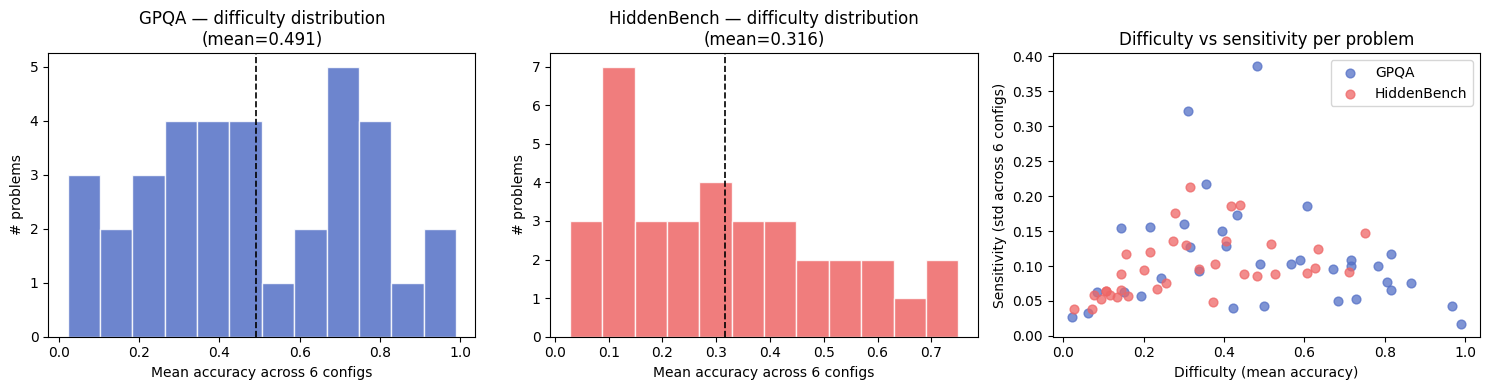

GPQA          r(difficulty, sensitivity)=-0.149  p=0.3930
HiddenBench   r(difficulty, sensitivity)=0.447  p=0.0071


In [5]:
merged = difficulty_df.merge(sensitivity, on=['dataset', 'qid'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ds in zip(axes[:2], DATASETS):
    sub = merged[merged['dataset'] == ds]
    ax.hist(sub['difficulty'], bins=12, color=('#5470C6' if ds=='gpqa' else '#EE6666'),
            edgecolor='white', alpha=0.85)
    ax.axvline(sub['difficulty'].mean(), color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Mean accuracy across 6 configs')
    ax.set_ylabel('# problems')
    ax.set_title(f'{DS_LABELS[ds]} — difficulty distribution\n(mean={sub["difficulty"].mean():.3f})')

ax = axes[2]
for ds in DATASETS:
    sub = merged[merged['dataset'] == ds]
    ax.scatter(sub['difficulty'], sub['sensitivity'],
               label=DS_LABELS[ds], alpha=0.75, s=40,
               color='#5470C6' if ds=='gpqa' else '#EE6666')
ax.set_xlabel('Difficulty (mean accuracy)')
ax.set_ylabel('Sensitivity (std across 6 configs)')
ax.set_title('Difficulty vs sensitivity per problem')
ax.legend()

plt.tight_layout()
plt.show()

for ds in DATASETS:
    sub = merged[merged['dataset'] == ds]
    r, p = sp_stats.pearsonr(sub['difficulty'], sub['sensitivity'])
    print(f'{DS_LABELS[ds]:12s}  r(difficulty, sensitivity)={r:.3f}  p={p:.4f}')

---
## Part 2 — Heatmap: Normalized Accuracy per (Config × Problem)

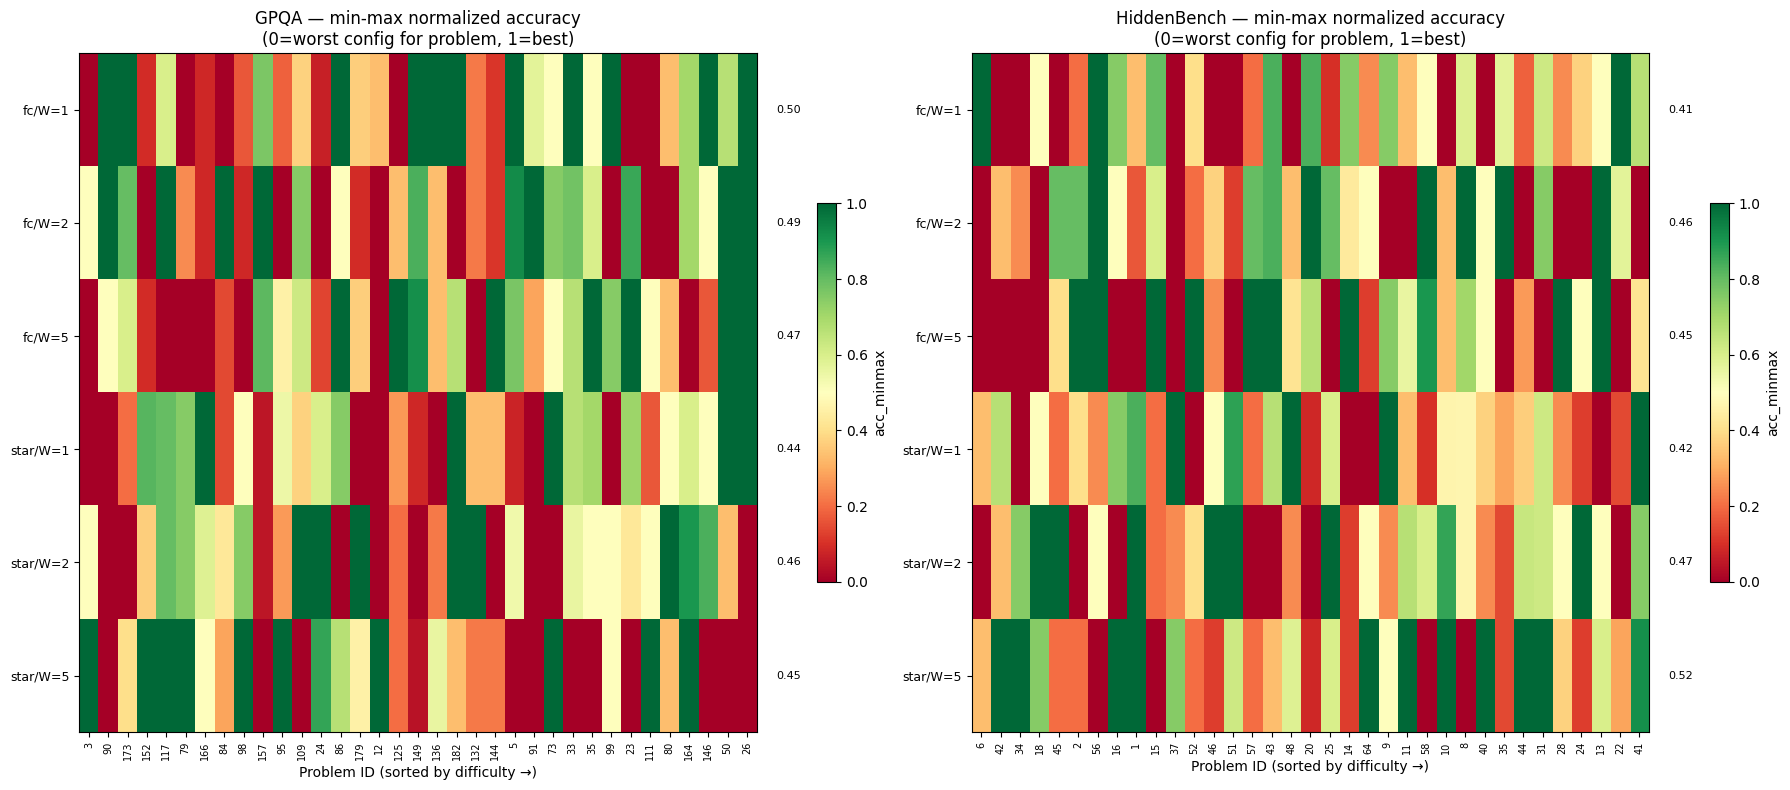

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, ds in zip(axes, DATASETS):
    sub = tasks_df[tasks_df['dataset'] == ds]
    pivot = sub.pivot_table(index='config', columns='qid', values='acc_minmax')
    pivot = pivot.reindex(CONFIG_ORDER)
    qids_sorted = (
        sub.groupby('qid')['difficulty'].first()
        .sort_values()
        .index.tolist()
    )
    pivot = pivot[qids_sorted]

    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                   vmin=0, vmax=1, interpolation='nearest')
    ax.set_yticks(range(len(CONFIG_ORDER)))
    ax.set_yticklabels(CONFIG_ORDER, fontsize=9)
    ax.set_xticks(range(len(qids_sorted)))
    ax.set_xticklabels(qids_sorted, rotation=90, fontsize=7)
    ax.set_xlabel('Problem ID (sorted by difficulty →)')
    ax.set_title(f'{DS_LABELS[ds]} — min-max normalized accuracy\n(0=worst config for problem, 1=best)')

    mean_per_config = pivot.mean(axis=1).round(3)
    for i, (cfg, val) in enumerate(mean_per_config.items()):
        ax.text(len(qids_sorted) + 0.5, i, f'{val:.2f}',
                va='center', ha='left', fontsize=8)

    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.08, label='acc_minmax')

plt.tight_layout()
plt.show()

---
## Part 3 — Config Comparison After Normalization

In [7]:
summary = (
    tasks_df.groupby(['dataset', 'topology', 'W'])
    .agg(
        raw_acc   =('accuracy',     'mean'),
        acc_minmax=('acc_minmax',   'mean'),
        acc_zscore=('acc_zscore',   'mean'),
        acc_resid =('acc_residual', 'mean'),
    )
    .round(4)
)
print(summary.to_string())

                        raw_acc  acc_minmax  acc_zscore  acc_resid
dataset     topology W                                            
gpqa        fc       1   0.5019      0.5037      0.0727     0.0108
                     2   0.4971      0.4857      0.0190     0.0060
                     5   0.5067      0.4745      0.0066     0.0156
            star     1   0.4752      0.4420     -0.0659    -0.0159
                     2   0.4876      0.4574      0.0117    -0.0035
                     5   0.4781      0.4452     -0.0441    -0.0130
hiddenbench fc       1   0.2990      0.4083     -0.1299    -0.0173
                     2   0.3210      0.4574      0.0019     0.0046
                     5   0.3210      0.4512      0.0088     0.0046
            star     1   0.3038      0.4170     -0.1002    -0.0125
                     2   0.3248      0.4733      0.0509     0.0084
                     5   0.3286      0.5158      0.1686     0.0122


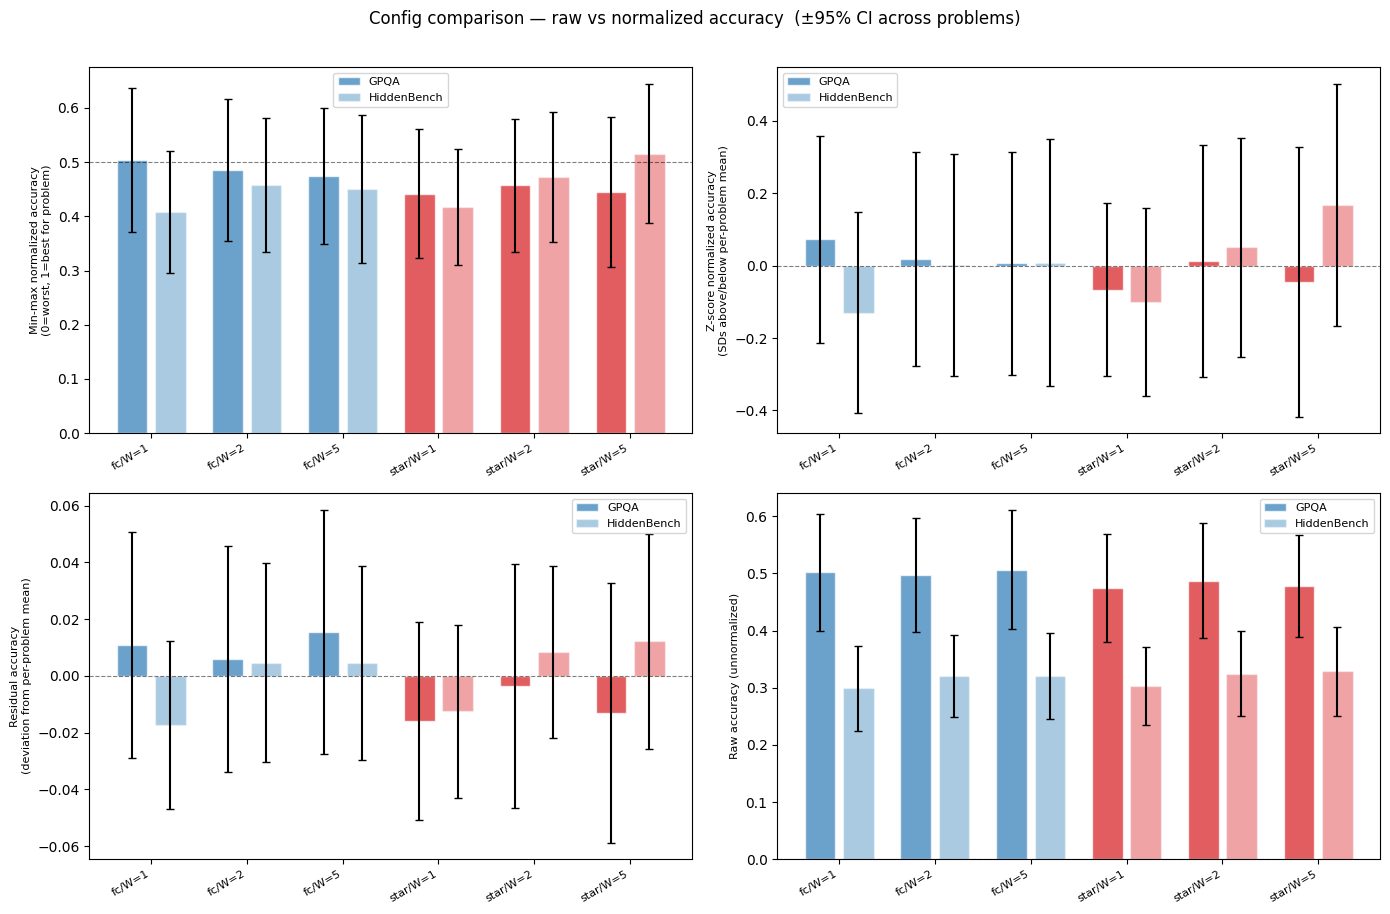

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)

metrics = [
    ('acc_minmax',   'Min-max normalized accuracy\n(0=worst, 1=best for problem)'),
    ('acc_zscore',   'Z-score normalized accuracy\n(SDs above/below per-problem mean)'),
    ('acc_residual', 'Residual accuracy\n(deviation from per-problem mean)'),
    ('accuracy',     'Raw accuracy (unnormalized)'),
]

for ax, (metric, ylabel) in zip(axes.flat, metrics):
    for ds_idx, ds in enumerate(DATASETS):
        sub = tasks_df[tasks_df['dataset'] == ds]
        x_base = np.array(range(len(CONFIG_ORDER))) * 2.5 + ds_idx * 1.0
        means = [sub[sub['config'] == c][metric].mean() for c in CONFIG_ORDER]
        sems  = [sub[sub['config'] == c][metric].sem()  for c in CONFIG_ORDER]
        bars  = ax.bar(
            x_base, means,
            yerr=[1.96 * s for s in sems],
            width=0.8,
            color=CONFIG_COLORS,
            alpha=0.7 if ds_idx == 0 else 0.4,
            edgecolor='white',
            capsize=3,
            label=DS_LABELS[ds],
        )

    ax.axhline(0 if 'minmax' not in metric else 0.5,
               color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xticks(np.array(range(len(CONFIG_ORDER))) * 2.5 + 0.5)
    ax.set_xticklabels(CONFIG_ORDER, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.legend(fontsize=8)

fig.suptitle('Config comparison — raw vs normalized accuracy  (±95% CI across problems)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

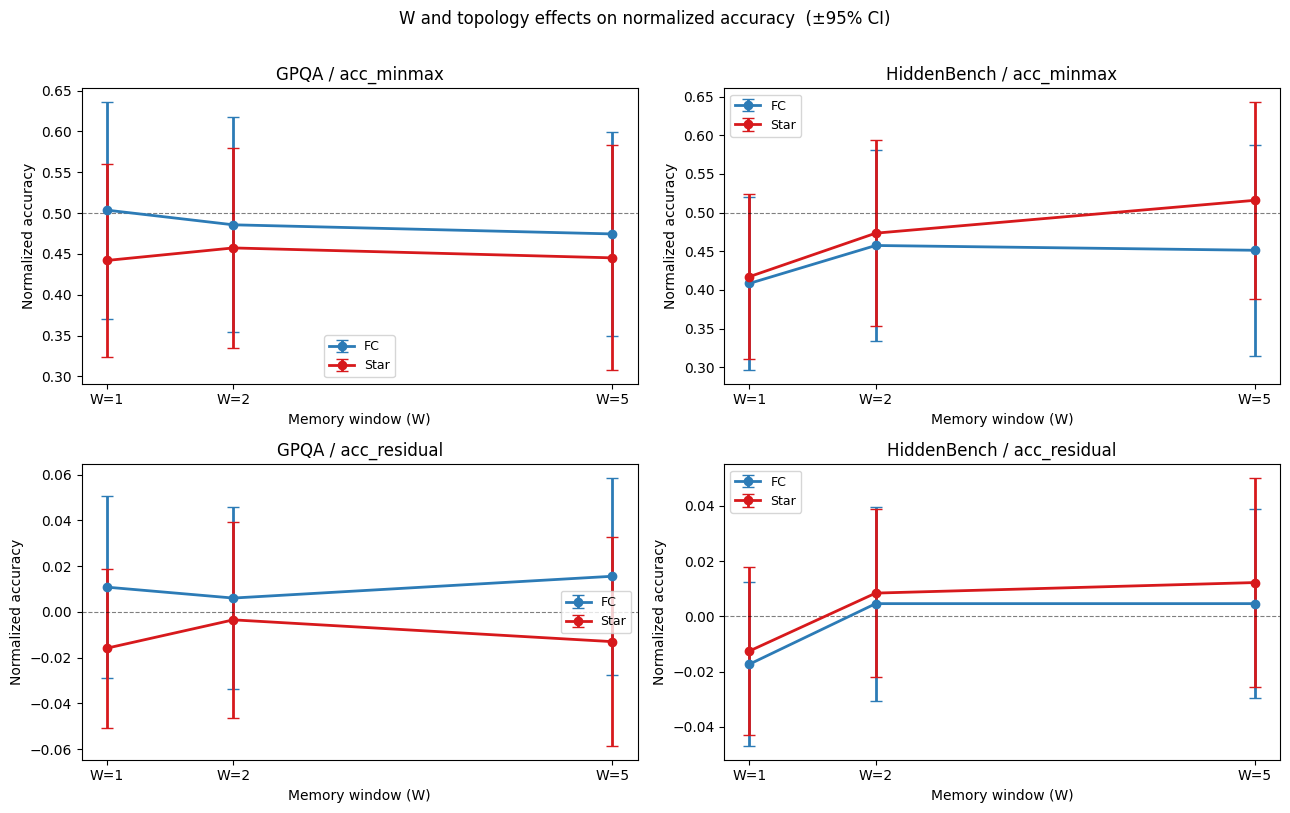

=== Kruskal-Wallis: W effect on acc_minmax ===
  GPQA         fc     H=0.229  p=0.8920
  GPQA         star   H=0.053  p=0.9736
  HiddenBench  fc     H=0.386  p=0.8243
  HiddenBench  star   H=0.841  p=0.6567

=== MWU: topology fc vs star on acc_minmax ===
  GPQA         W=1  fc=0.504  star=0.442  p=0.4543
  GPQA         W=2  fc=0.486  star=0.457  p=0.7992
  GPQA         W=5  fc=0.475  star=0.445  p=0.7042
  HiddenBench  W=1  fc=0.408  star=0.417  p=0.8596
  HiddenBench  W=2  fc=0.457  star=0.473  p=0.8966
  HiddenBench  W=5  fc=0.451  star=0.516  p=0.3566


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, metric in enumerate(['acc_minmax', 'acc_residual']):
    for col, ds in enumerate(DATASETS):
        ax  = axes[row][col]
        sub = tasks_df[tasks_df['dataset'] == ds]

        for topo in TOPOS:
            t_sub  = sub[sub['topology'] == topo]
            means  = [t_sub[t_sub['W'] == w][metric].mean() for w in W_VALUES]
            sems   = [t_sub[t_sub['W'] == w][metric].sem()  for w in W_VALUES]
            ax.errorbar(
                W_VALUES, means, yerr=[1.96*s for s in sems],
                marker='o', linewidth=2, capsize=4,
                color=T_COLORS[topo], label=T_LABELS[topo],
            )

        ax.set_xticks(W_VALUES)
        ax.set_xticklabels([f'W={w}' for w in W_VALUES])
        ax.set_xlabel('Memory window (W)')
        ax.set_ylabel('Normalized accuracy')
        ax.set_title(f'{DS_LABELS[ds]} / {metric}')
        ax.legend(fontsize=9)

        if 'minmax' in metric:
            ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        else:
            ax.axhline(0.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

fig.suptitle('W and topology effects on normalized accuracy  (±95% CI)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('=== Kruskal-Wallis: W effect on acc_minmax ===')
for ds in DATASETS:
    for topo in TOPOS:
        groups = [
            tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo) &
                     (tasks_df['W']==w)]['acc_minmax'].dropna().values
            for w in W_VALUES
        ]
        stat, p = sp_stats.kruskal(*groups)
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  H={stat:.3f}  p={p:.4f}')

print()
print('=== MWU: topology fc vs star on acc_minmax ===')
for ds in DATASETS:
    for w in W_VALUES:
        fc   = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']=='fc')   & (tasks_df['W']==w)]['acc_minmax']
        star = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']=='star') & (tasks_df['W']==w)]['acc_minmax']
        stat, p = sp_stats.mannwhitneyu(fc, star, alternative='two-sided')
        print(f'  {DS_LABELS[ds]:12s} W={w}  fc={fc.mean():.3f}  star={star.mean():.3f}  p={p:.4f}')

---
## Part 4 — Config Ranking per Problem

In [10]:
def add_ranks(grp):
    grp = grp.copy()
    grp['rank'] = grp['accuracy'].rank(ascending=False, method='average')
    return grp

tasks_df = (
    tasks_df
    .groupby(['dataset', 'qid'], group_keys=False)
    .apply(add_ranks)
)

print('Mean rank per config (1=best, 6=worst):')
rank_summary = (
    tasks_df.groupby(['dataset', 'config'])['rank']
    .mean()
    .round(3)
    .unstack('config')
    .reindex(columns=CONFIG_ORDER)
)
print(rank_summary.to_string())
print()
print('Fraction of problems where config is rank-1 (best):')
rank1 = (
    tasks_df[tasks_df['rank'] == 1]
    .groupby(['dataset', 'config'])
    .size()
    .div(35)
    .round(3)
    .unstack('config')
    .reindex(columns=CONFIG_ORDER)
    .fillna(0)
)
print(rank1.to_string())

Mean rank per config (1=best, 6=worst):
config       fc/W=1  fc/W=2  fc/W=5  star/W=1  star/W=2  star/W=5
dataset                                                          
gpqa          3.429   3.486     3.5     3.500     3.571     3.514
hiddenbench   3.843   3.429     3.5     3.643     3.443     3.143

Fraction of problems where config is rank-1 (best):
config       fc/W=1  fc/W=2  fc/W=5  star/W=1  star/W=2  star/W=5
dataset                                                          
gpqa          0.200   0.086   0.114     0.029     0.143     0.229
hiddenbench   0.057   0.114   0.200     0.114     0.171     0.257


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_51420/87209986.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_ranks)


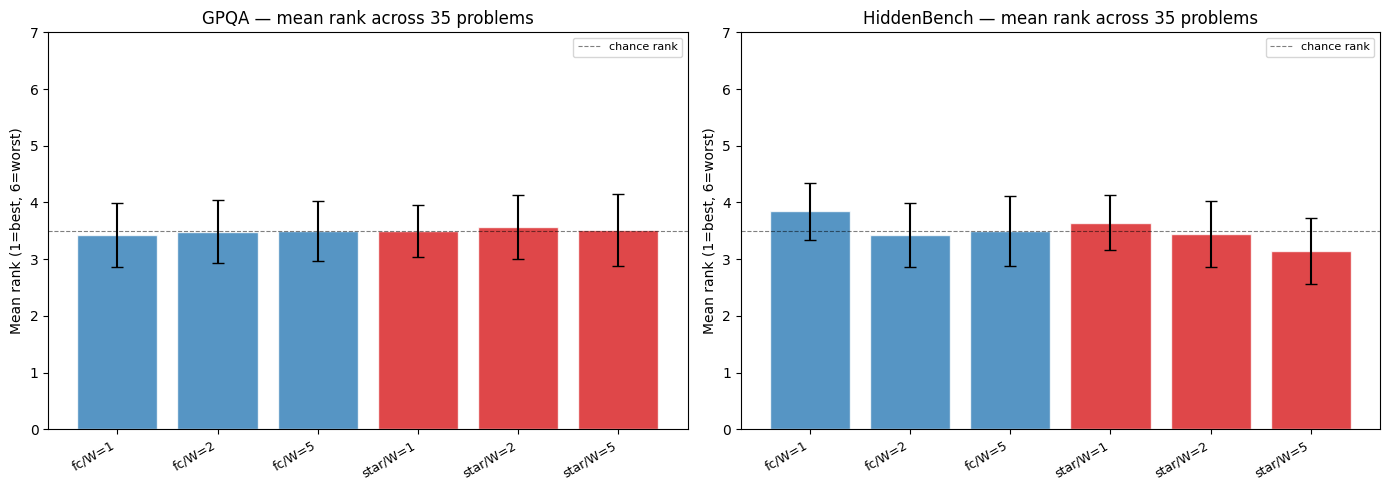

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, DATASETS):
    sub = tasks_df[tasks_df['dataset'] == ds]
    means = [sub[sub['config'] == c]['rank'].mean() for c in CONFIG_ORDER]
    sems  = [sub[sub['config'] == c]['rank'].sem()  for c in CONFIG_ORDER]
    bars = ax.bar(
        range(len(CONFIG_ORDER)), means,
        yerr=[1.96*s for s in sems],
        color=CONFIG_COLORS, alpha=0.8, capsize=4, edgecolor='white',
    )
    ax.axhline(3.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5,
               label='chance rank')
    ax.set_xticks(range(len(CONFIG_ORDER)))
    ax.set_xticklabels(CONFIG_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Mean rank (1=best, 6=worst)')
    ax.set_ylim(0, 7)
    ax.set_title(f'{DS_LABELS[ds]} — mean rank across 35 problems')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Part 5 — Does Config Effect Depend on Problem Difficulty?

Correlation: difficulty ~ config sensitivity
  GPQA          r(diff, std)=-0.149 p=0.3930  r(diff, range)=-0.138 p=0.4286
  HiddenBench   r(diff, std)=0.447 p=0.0071  r(diff, range)=0.523 p=0.0013


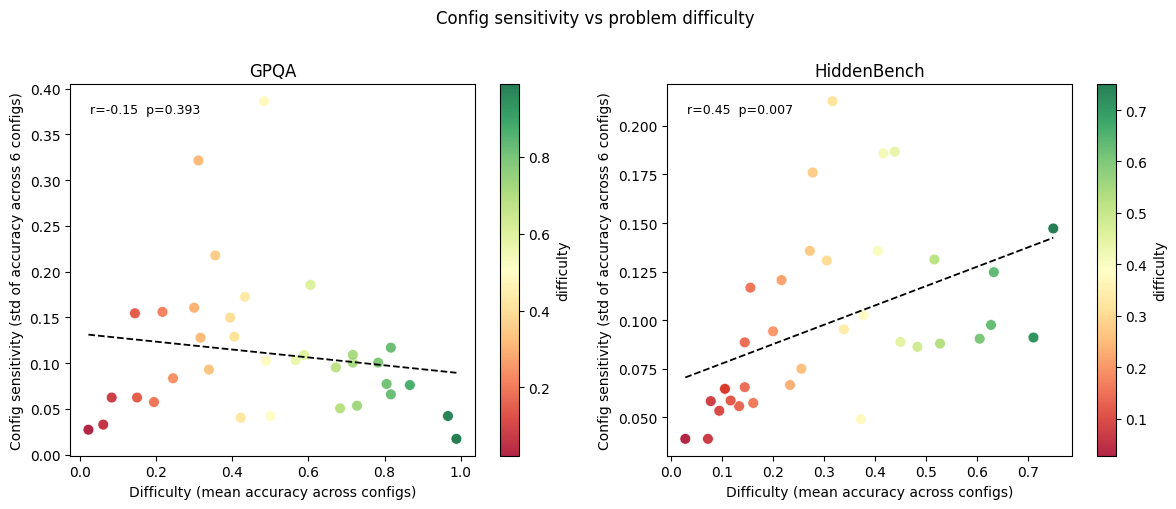

In [12]:
problem_stats = (
    tasks_df.groupby(['dataset', 'qid'])
    .agg(
        difficulty  =('accuracy', 'mean'),
        config_range=('accuracy', lambda x: x.max() - x.min()),
        config_std  =('accuracy', 'std'),
    )
    .reset_index()
)

print('Correlation: difficulty ~ config sensitivity')
for ds in DATASETS:
    sub = problem_stats[problem_stats['dataset'] == ds]
    r_std,   p_std   = sp_stats.pearsonr(sub['difficulty'], sub['config_std'])
    r_range, p_range = sp_stats.pearsonr(sub['difficulty'], sub['config_range'])
    print(f'  {DS_LABELS[ds]:12s}  r(diff, std)={r_std:.3f} p={p_std:.4f}  '
          f'r(diff, range)={r_range:.3f} p={p_range:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, ds in zip(axes, DATASETS):
    sub = problem_stats[problem_stats['dataset'] == ds]
    sc = ax.scatter(
        sub['difficulty'], sub['config_std'],
        c=sub['difficulty'], cmap='RdYlGn',
        s=60, alpha=0.85, edgecolors='white', linewidths=0.5,
    )
    m, b = np.polyfit(sub['difficulty'], sub['config_std'], 1)
    xs = np.linspace(sub['difficulty'].min(), sub['difficulty'].max(), 50)
    ax.plot(xs, m*xs + b, color='black', linewidth=1.3, linestyle='--')
    r, p = sp_stats.pearsonr(sub['difficulty'], sub['config_std'])
    ax.text(0.05, 0.95, f'r={r:.2f}  p={p:.3f}',
            transform=ax.transAxes, fontsize=9, va='top')
    ax.set_xlabel('Difficulty (mean accuracy across configs)')
    ax.set_ylabel('Config sensitivity (std of accuracy across 6 configs)')
    ax.set_title(f'{DS_LABELS[ds]}')
    plt.colorbar(sc, ax=ax, label='difficulty')

fig.suptitle('Config sensitivity vs problem difficulty', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
tasks_with_stats = tasks_df.merge(
    problem_stats[['dataset', 'qid', 'difficulty', 'config_range', 'config_std']],
    on=['dataset', 'qid'], suffixes=('', '_ps'),
)

print('=== Normalized accuracy by difficulty tertile and config ===')
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}')
    sub = tasks_with_stats[tasks_with_stats['dataset'] == ds]
    q33, q67 = sub['difficulty'].quantile([0.33, 0.67])
    labels = ['easy (top 33%)', 'medium', 'hard (bottom 33%)']
    masks  = [
        sub['difficulty'] >= q67,
        (sub['difficulty'] >= q33) & (sub['difficulty'] < q67),
        sub['difficulty'] < q33,
    ]
    for lbl, mask in zip(labels, masks):
        tier = sub[mask]
        vals = [tier[tier['config'] == c]['acc_minmax'].mean() for c in CONFIG_ORDER]
        print(f'  {lbl:22s}  ' + '  '.join(f'{c}:{v:.3f}' for c, v in zip(CONFIG_ORDER, vals)))

=== Normalized accuracy by difficulty tertile and config ===

GPQA
  easy (top 33%)          fc/W=1:0.606  fc/W=2:0.599  fc/W=5:0.600  star/W=1:0.571  star/W=2:0.463  star/W=5:0.319
  medium                  fc/W=1:0.539  fc/W=2:0.341  fc/W=5:0.567  star/W=1:0.318  star/W=2:0.497  star/W=5:0.380
  hard (bottom 33%)       fc/W=1:0.353  fc/W=2:0.520  fc/W=5:0.236  star/W=1:0.437  star/W=2:0.409  star/W=5:0.653

HiddenBench
  easy (top 33%)          fc/W=1:0.438  fc/W=2:0.513  fc/W=5:0.469  star/W=1:0.350  star/W=2:0.528  star/W=5:0.537
  medium                  fc/W=1:0.371  fc/W=2:0.450  fc/W=5:0.564  star/W=1:0.438  star/W=2:0.433  star/W=5:0.448
  hard (bottom 33%)       fc/W=1:0.417  fc/W=2:0.405  fc/W=5:0.309  star/W=1:0.467  star/W=2:0.458  star/W=5:0.567


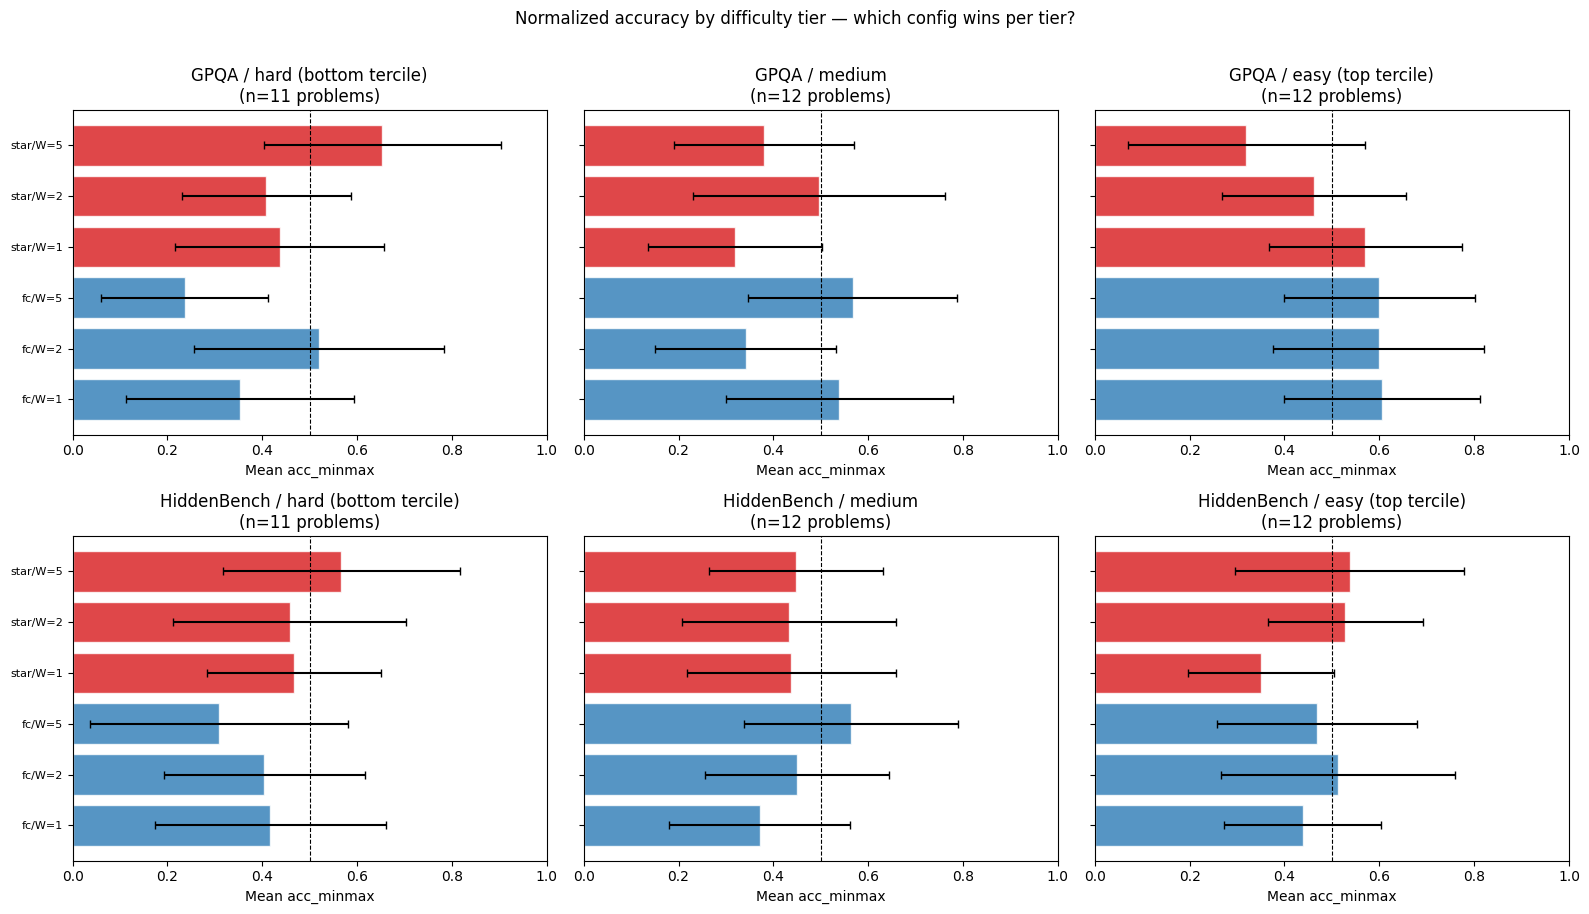

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
difficulty_labels = ['hard (bottom tercile)', 'medium', 'easy (top tercile)']

for row, ds in enumerate(DATASETS):
    sub = tasks_with_stats[tasks_with_stats['dataset'] == ds]
    q33, q67 = sub['difficulty'].quantile([0.33, 0.67])
    tier_masks = [
        sub['difficulty'] < q33,
        (sub['difficulty'] >= q33) & (sub['difficulty'] < q67),
        sub['difficulty'] >= q67,
    ]

    for col, (lbl, mask) in enumerate(zip(difficulty_labels, tier_masks)):
        ax    = axes[row][col]
        tier  = sub[mask]
        means = [tier[tier['config'] == c]['acc_minmax'].mean() for c in CONFIG_ORDER]
        sems  = [tier[tier['config'] == c]['acc_minmax'].sem()  for c in CONFIG_ORDER]
        ax.barh(
            range(len(CONFIG_ORDER)), means,
            xerr=[1.96*s for s in sems],
            color=CONFIG_COLORS, alpha=0.8, capsize=3, edgecolor='white',
        )
        ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
        ax.set_yticks(range(len(CONFIG_ORDER)))
        ax.set_yticklabels(CONFIG_ORDER, fontsize=8)
        ax.set_xlabel('Mean acc_minmax')
        ax.set_xlim(0, 1)
        ax.set_title(f'{DS_LABELS[ds]} / {lbl}\n(n={mask.sum()//len(CONFIG_ORDER)} problems)')

fig.suptitle('Normalized accuracy by difficulty tier — which config wins per tier?',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Part 6 — Cross-Dataset Comparison

After normalization, we can compare config effects across datasets more fairly.

In [15]:
print('=== MWU: GPQA vs HiddenBench on acc_minmax per config ===')
for c in CONFIG_ORDER:
    g = tasks_df[(tasks_df['dataset']=='gpqa')        & (tasks_df['config']==c)]['acc_minmax']
    h = tasks_df[(tasks_df['dataset']=='hiddenbench') & (tasks_df['config']==c)]['acc_minmax']
    stat, p = sp_stats.mannwhitneyu(g, h, alternative='two-sided')
    print(f'  {c:10s}  GPQA={g.mean():.3f}  HiddenBench={h.mean():.3f}  p={p:.4f}')

print()
print('=== Friedman test: W effect per dataset (acc_minmax) ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub   = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        pivot = sub.pivot_table(index='qid', columns='W', values='acc_minmax')
        if pivot.shape[1] == 3 and not pivot.isnull().any().any():
            stat, p = sp_stats.friedmanchisquare(*[pivot[w].values for w in W_VALUES])
            print(f'  {DS_LABELS[ds]:12s} {topo:5s}  χ²={stat:.3f}  p={p:.4f}')

=== MWU: GPQA vs HiddenBench on acc_minmax per config ===
  fc/W=1      GPQA=0.504  HiddenBench=0.408  p=0.2962
  fc/W=2      GPQA=0.486  HiddenBench=0.457  p=0.8684
  fc/W=5      GPQA=0.475  HiddenBench=0.451  p=0.7214
  star/W=1    GPQA=0.442  HiddenBench=0.417  p=0.8552
  star/W=2    GPQA=0.457  HiddenBench=0.473  p=0.8732
  star/W=5    GPQA=0.445  HiddenBench=0.516  p=0.3791

=== Friedman test: W effect per dataset (acc_minmax) ===
  GPQA         fc     χ²=1.217  p=0.5443
  GPQA         star   χ²=0.065  p=0.9680
  HiddenBench  fc     χ²=1.492  p=0.4743
  HiddenBench  star   χ²=1.453  p=0.4836


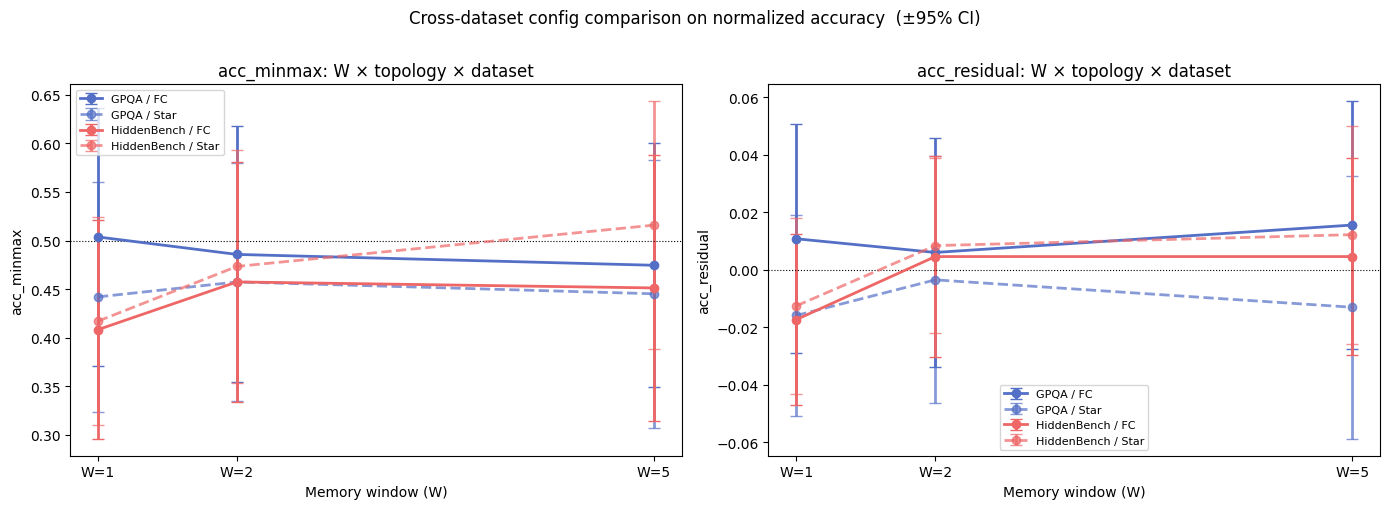

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['acc_minmax', 'acc_residual']):
    for ds_idx, ds in enumerate(DATASETS):
        sub = tasks_df[tasks_df['dataset'] == ds]
        for topo_idx, topo in enumerate(TOPOS):
            t_sub = sub[sub['topology'] == topo]
            means = [t_sub[t_sub['W'] == w][metric].mean() for w in W_VALUES]
            sems  = [t_sub[t_sub['W'] == w][metric].sem()  for w in W_VALUES]
            style = '-' if topo == 'fc' else '--'
            color = '#5470C6' if ds == 'gpqa' else '#EE6666'
            ax.errorbar(
                W_VALUES, means, yerr=[1.96*s for s in sems],
                linestyle=style, marker='o', linewidth=2, capsize=4,
                color=color, alpha=0.7 + 0.3*(topo=='fc'),
                label=f'{DS_LABELS[ds]} / {T_LABELS[topo]}',
            )
    ax.axhline(0 if metric == 'acc_residual' else 0.5,
               color='black', linestyle=':', linewidth=0.8)
    ax.set_xticks(W_VALUES)
    ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_xlabel('Memory window (W)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}: W × topology × dataset')
    ax.legend(fontsize=8)

fig.suptitle('Cross-dataset config comparison on normalized accuracy  (±95% CI)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Summary Table

In [17]:
full_summary = (
    tasks_df.groupby(['dataset', 'topology', 'W'])
    .agg(
        raw_acc      =('accuracy',     'mean'),
        acc_minmax   =('acc_minmax',   'mean'),
        acc_zscore   =('acc_zscore',   'mean'),
        acc_residual =('acc_residual', 'mean'),
        mean_rank    =('rank',         'mean'),
    )
    .round(4)
)
print(full_summary.to_string())

                        raw_acc  acc_minmax  acc_zscore  acc_residual  mean_rank
dataset     topology W                                                          
gpqa        fc       1   0.5019      0.5037      0.0727        0.0108     3.4286
                     2   0.4971      0.4857      0.0190        0.0060     3.4857
                     5   0.5067      0.4745      0.0066        0.0156     3.5000
            star     1   0.4752      0.4420     -0.0659       -0.0159     3.5000
                     2   0.4876      0.4574      0.0117       -0.0035     3.5714
                     5   0.4781      0.4452     -0.0441       -0.0130     3.5143
hiddenbench fc       1   0.2990      0.4083     -0.1299       -0.0173     3.8429
                     2   0.3210      0.4574      0.0019        0.0046     3.4286
                     5   0.3210      0.4512      0.0088        0.0046     3.5000
            star     1   0.3038      0.4170     -0.1002       -0.0125     3.6429
                     2   0.3